In [13]:
##### Overlays capital and labor AND INCOME with priority maps: calculations and figures

import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import matplotlib.transforms as transforms
from matplotlib.lines import Line2D
import rasterio.features
from matplotlib import gridspec
import rioxarray as rio
import matplotlib.colors as mcolors
from rasterio.plot import show
import os
import textwrap
import rioxarray
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from rasterio.enums import Resampling

In [6]:
##### Load data

# Get the current working directory
cd = Path.cwd().parent 

# capital rasters
capital = f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD.tif"
capital_country_avg = f"{cd}/Results/Raster_model/reprojected/rescaled_capital_USD_country_avg.tif"

# labor rasters
labor = f"{cd}/Results/Raster_model/reprojected/rescaled_jobs.tif"
labor_country_avg = f"{cd}/Results/Raster_model/reprojected/rescaled_jobs_country_avg.tif"

# production raster
production = f"{cd}/Results/Raster_model/reprojected/total_production_tonnes_2020.tif"

# GDP pc percentile rasters
GDP_pc_percentiles_national = f"{cd}/Data/Clean/GDP_percentiles/GDP_pc_percentiles_reprojected.tif"
GDP_pc_percentiles_global = f"{cd}/Data/Clean/GDP_percentiles/global_GDP_pc_percentiles_reprojected.tif"

# priority rasters
# 0 = no in top 30%, 1 = in top 30%, not PA, 2 = in top 30%, already PA
biodiversity_with_PA = f"{cd}/Data/Clean/Priority_areas/biodiversity_with_PA.tif"
all_with_PA = f"{cd}/Data/Clean/Priority_areas/all_with_PA.tif"

# country boundaries 
country_shp = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')
country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

# Import country data
national_capital = pd.read_csv(f"{cd}/Results/Raster_model/intermediate_outputs/national_scaling_factors_capital.csv")
national_labor = pd.read_csv(f"{cd}/Results/Raster_model/intermediate_outputs/national_scaling_factors_labor.csv")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/priority_areas"

In [14]:
### Step 1: align rasters

# --- Load everything as DataArrays ---
capital_da              = rioxarray.open_rasterio(capital, masked=True)
capital_avg_da          = rioxarray.open_rasterio(capital_country_avg, masked=True)
labor_da                = rioxarray.open_rasterio(labor, masked=True)
labor_avg_da            = rioxarray.open_rasterio(labor_country_avg, masked=True)
gdp_pc_national_da      = rioxarray.open_rasterio(GDP_pc_percentiles_national, masked=True)
gdp_pc_global_da        = rioxarray.open_rasterio(GDP_pc_percentiles_global, masked=True)
biodiversity_da         = rioxarray.open_rasterio(biodiversity_with_PA, masked=True)
all_da                  = rioxarray.open_rasterio(all_with_PA, masked=True)

# --- Align everything to the national percentile grid (arbitrary common reference) ---
def match_grid(da, target):
    return da.rio.reproject_match(target, resampling=Resampling.nearest)

capital_da       = match_grid(capital_da, gdp_pc_national_da)
capital_avg_da   = match_grid(capital_avg_da, gdp_pc_national_da)
labor_da         = match_grid(labor_da, gdp_pc_national_da)
labor_avg_da     = match_grid(labor_avg_da, gdp_pc_national_da)
gdp_pc_global_da = match_grid(gdp_pc_global_da, gdp_pc_national_da)
biodiversity_da  = match_grid(biodiversity_da, gdp_pc_national_da)
all_da           = match_grid(all_da, gdp_pc_national_da)

percentile_lookup = {'national': gdp_pc_national_da, 'global': gdp_pc_global_da}
priority_lookup    = {'biodiversity': biodiversity_da, 'all': all_da}

In [15]:
##### Step 2: get priority area totals

def summarize_priority_totals(scenario='biodiversity'):
    """Sum capital/labor (modeled + country avg) split into 'Not priority' vs 'Priority area'."""
    priority_da = priority_lookup[scenario]
    priority_arr = priority_da.squeeze().values

    value_arrs = {
        'capital_modeled':     capital_da.squeeze().values,
        'capital_country_avg': capital_avg_da.squeeze().values,
        'labor_modeled':       labor_da.squeeze().values,
        'labor_country_avg':   labor_avg_da.squeeze().values,
    }

    categories = {
        'Not priority':   priority_arr == 0,
        'Priority area':  priority_arr >= 1,   # combines "additional" + "already PA"
    }

    rows = []
    for cat_name, mask in categories.items():
        row = {'scenario': scenario, 'category': cat_name, 'n_pixels': int(np.sum(mask))}
        for val_name, val_arr in value_arrs.items():
            row[val_name] = np.nansum(val_arr[mask])
        rows.append(row)
    return pd.DataFrame(rows)

summarize_priority_totals('biodiversity')

,scenario,category,n_pixels,capital_modeled,capital_country_avg,labor_modeled,labor_country_avg
0,biodiversity,Not priority,973316,4.526319e+12,4.595703e+12,726739968.0,735817152.0
1,biodiversity,Priority area,417913,8.331266e+11,7.638572e+11,117386112.0,108360680.0


In [16]:
##### Step 3: define functions for plot 

def pct_by_percentile_within_mask(var_da, pctl_da, priority_mask):
    """% of the priority-area total for var, broken out by GDP-pc percentile (1-100)."""
    var  = var_da.squeeze().values.astype(float)
    pctl = pctl_da.squeeze().values.astype(float)

    nodata_var = var_da.rio.nodata
    if nodata_var is not None:
        var = np.where(var == nodata_var, np.nan, var)
    nodata_pctl = pctl_da.rio.nodata
    if nodata_pctl is not None:
        pctl = np.where(pctl == nodata_pctl, np.nan, pctl)

    valid = (~np.isnan(var) & ~np.isnan(pctl) & (pctl >= 1) & (pctl <= 100)
             & priority_mask)

    var_v  = var[valid]
    pctl_v = np.round(pctl[valid]).astype(int)

    total = np.nansum(var_v)  # total within priority area only

    df = pd.DataFrame({"percentile": pctl_v, "value": var_v})
    grouped = df.groupby("percentile")["value"].sum().reindex(range(1, 101), fill_value=0)

    return (grouped / total) * 100 if total > 0 else grouped


def smooth(series, window=9, polyorder=2):
    smoothed = savgol_filter(series.values, window_length=window, polyorder=polyorder, mode="interp")
    return pd.Series(smoothed, index=series.index)


def plot_capital_labor_priority(scenario='biodiversity', percentile_scope='national', save=True):
    """
    scenario: 'biodiversity' or 'all'
    percentile_scope: 'national' or 'global'
    """
    priority_da  = priority_lookup[scenario]
    pctl_da      = percentile_lookup[percentile_scope]
    priority_mask = priority_da.squeeze().values >= 1  # priority area = tier 1 or 2

    capital_pct     = smooth(pct_by_percentile_within_mask(capital_da, pctl_da, priority_mask))
    capital_avg_pct = smooth(pct_by_percentile_within_mask(capital_avg_da, pctl_da, priority_mask))
    labor_pct       = smooth(pct_by_percentile_within_mask(labor_da, pctl_da, priority_mask))
    labor_avg_pct   = smooth(pct_by_percentile_within_mask(labor_avg_da, pctl_da, priority_mask))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    ax = axes[0]
    ax.plot(capital_pct.index, capital_pct.values, label="Capital (modeled)",
            color="#1b9e77", linewidth=2)
    ax.plot(capital_avg_pct.index, capital_avg_pct.values, label="Capital (country avg)",
            color="#1b9e77", linewidth=2, linestyle="--")
    ax.set_xlabel(f"GDP pc percentile ({percentile_scope})")
    ax.set_ylabel("% of total exposed (within priority area)")
    ax.set_title("Capital")
    ax.set_xlim(1, 100)
    ax.legend(frameon=False)

    ax = axes[1]
    ax.plot(labor_pct.index, labor_pct.values, label="Labor (modeled)",
            color="#d95f02", linewidth=2)
    ax.plot(labor_avg_pct.index, labor_avg_pct.values, label="Labor (country avg)",
            color="#d95f02", linewidth=2, linestyle="--")
    ax.set_xlabel(f"GDP pc percentile ({percentile_scope})")
    ax.set_title("Labor")
    ax.set_xlim(1, 100)
    ax.legend(frameon=False)

    fig.suptitle(f"{scenario.capitalize()} scenario — priority-area exposure by {percentile_scope} income percentile",
                 y=1.03)
    plt.tight_layout()

    if save:
        plt.savefig(f"{fd}/priority_exposure_{scenario}_{percentile_scope}.png", dpi=300, bbox_inches="tight")
        plt.savefig(f"{fd}/priority_exposure_{scenario}_{percentile_scope}.pdf", bbox_inches="tight")
    plt.show()
    return fig

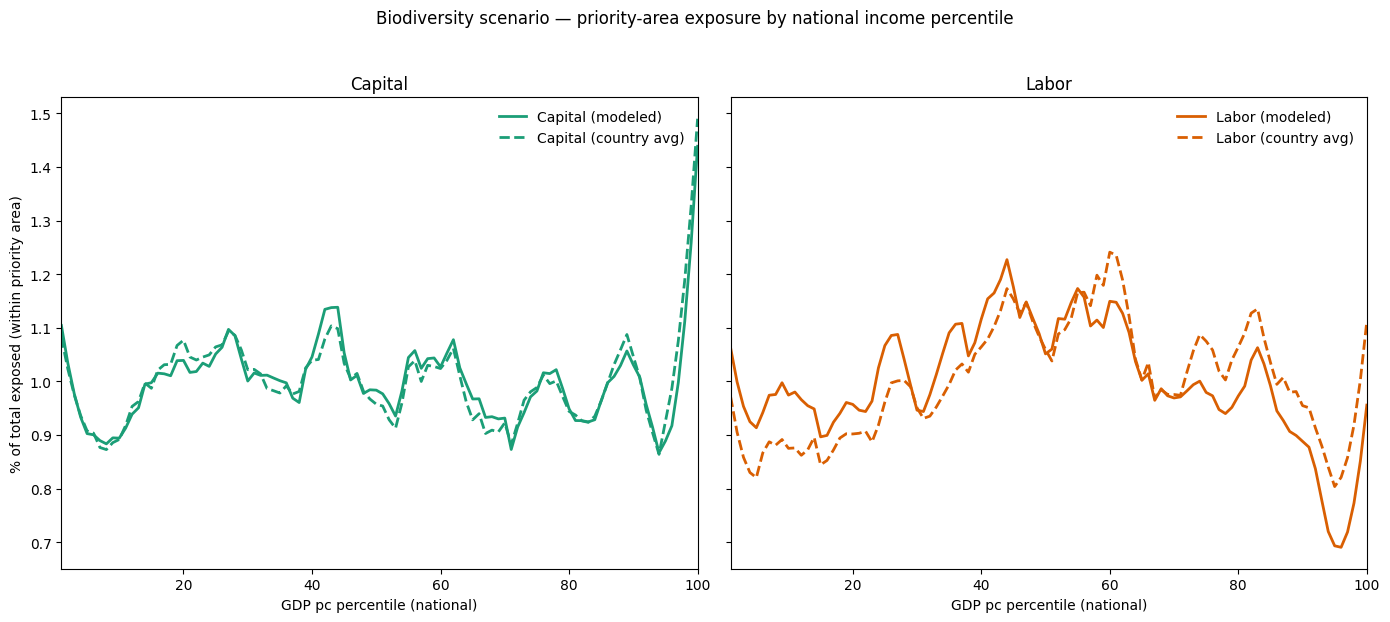

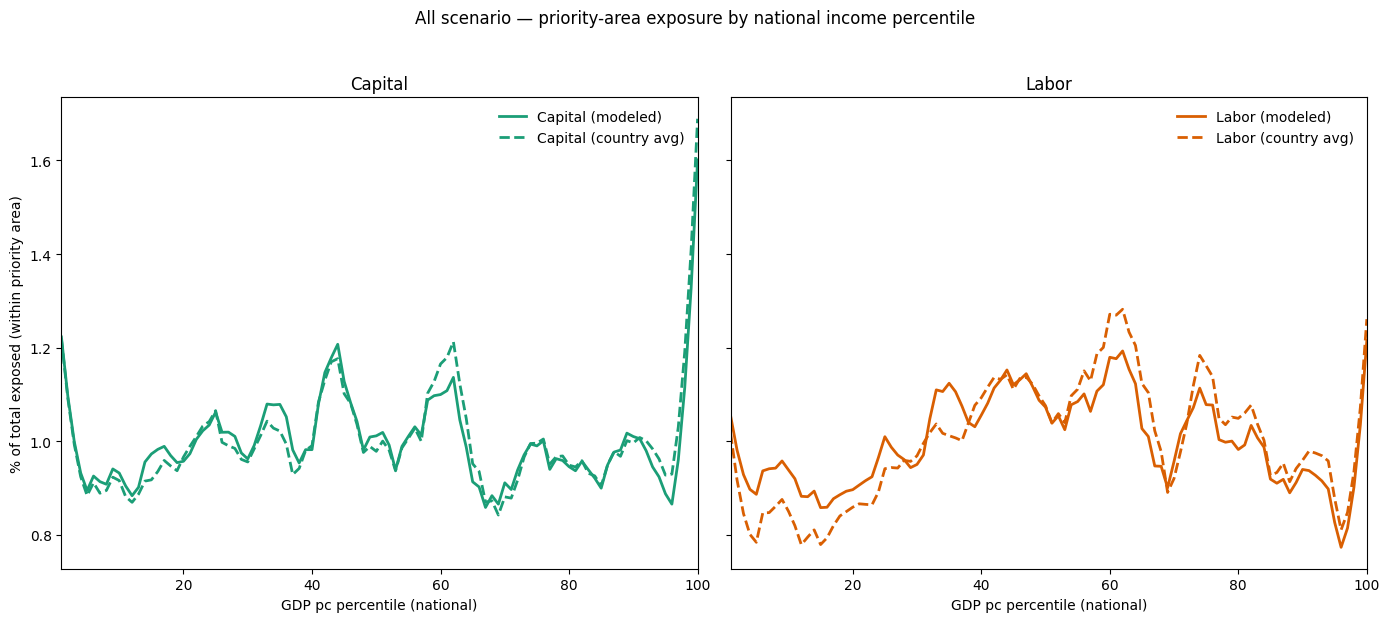

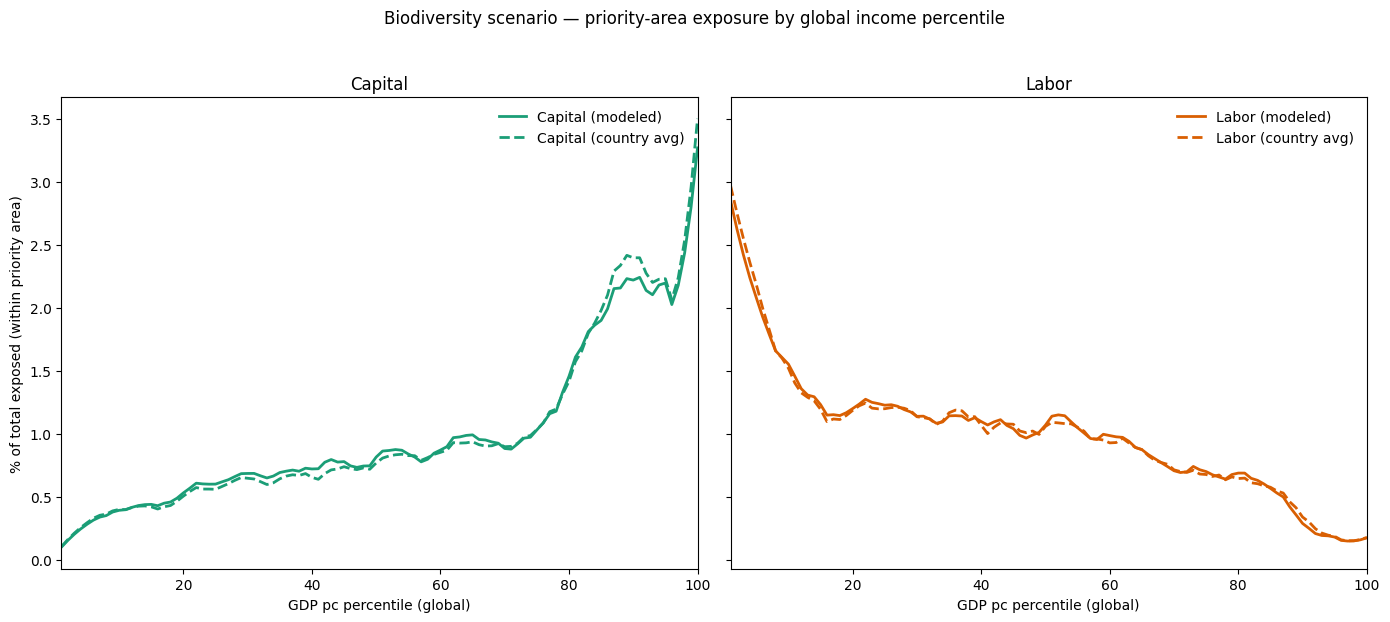

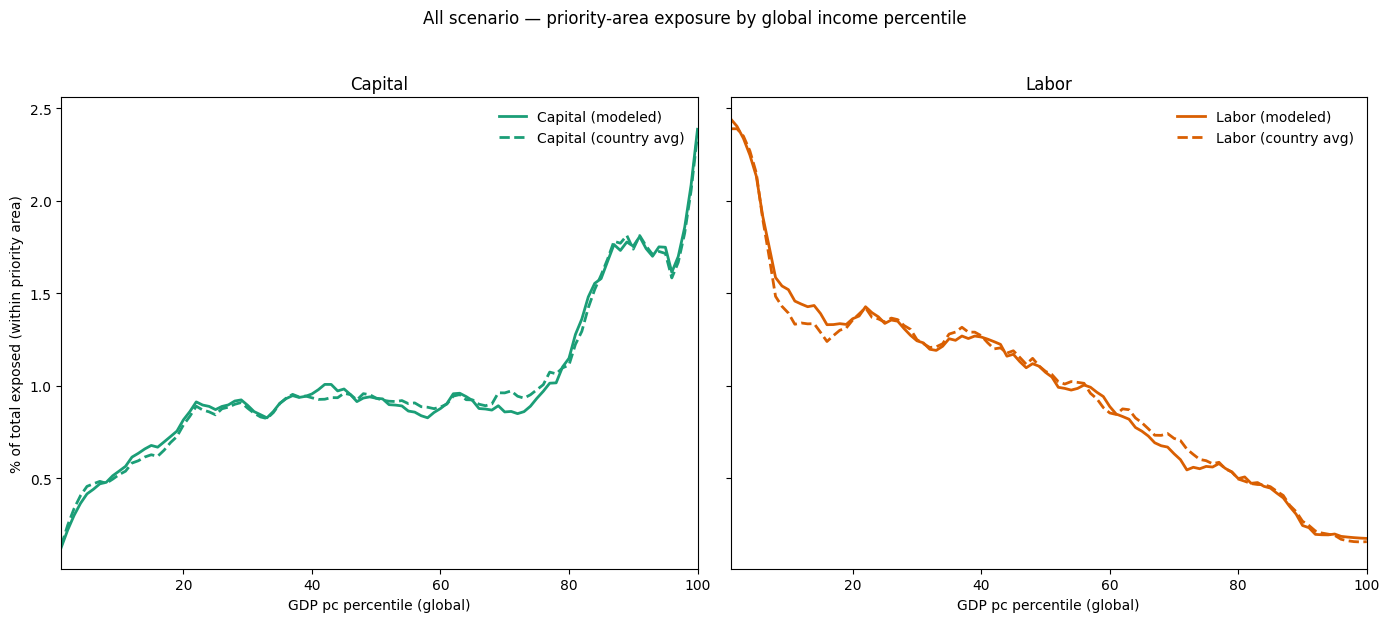

In [19]:
#### Run plots

plot_capital_labor_priority(scenario='biodiversity', percentile_scope='national');
plot_capital_labor_priority(scenario='all', percentile_scope='national');
plot_capital_labor_priority(scenario='biodiversity', percentile_scope='global');
plot_capital_labor_priority(scenario='all', percentile_scope='global');